# (26) poisson + BALLS16: (32, 16.0)

project = ```iP-VAE```, host = ```yoru```, device = ```cuda:0```

**Motivation**: <br>

Reproduce prev. results, but using loss per dim.

In [1]:
# HIDE CODE


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-progress-2025/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-progress-2025/figs')
tmp_dir = os.path.join(git_dir, 'jb-progress-2025/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, '_IterativeVAE'))
from figures.analysis import plot_convergence
from figures.imgs import plot_weights
from figures.fighelper import *
from main.train import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
device_idx = 0
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:0  ———  host: yoru

## Trainer

In [3]:
model_type = 'poisson'
npix = 16
cfg_vae, cfg_tr = default_configs(model_type, f'BALLS{npix}')

cfg_vae['n_latents'] = npix * 2

cfg_vae['seq_len'] = 32
cfg_tr['kl_beta'] = 16.0

+-------------+------------+
| Module Name | Num Params |
+-------------+------------+
|    IPVAE    |   8.5 K    |
|     ———     |    ———     |
|    layer    |   8.5 K    |
+-------------+------------+

poisson_BALLS16_t-32_z-[32]_cl-10,10_<grad|lin>
b400-ep1000-lr(0.0005)_beta(16:0.1)_temp(0.01:0.5)_gr(5000)_(2025_03_02,18:11)

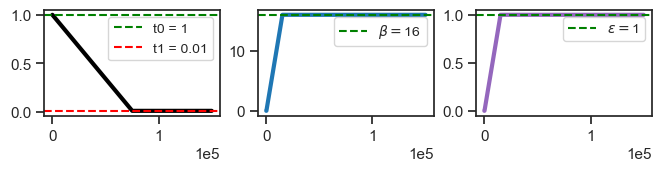

In [4]:
tr = Trainer(
    model=MODEL_CLASSES[model_type](CFG_CLASSES[model_type](**cfg_vae)),
    cfg=ConfigTrain(**cfg_tr),
    device=device,
)

tr.model.print()
print(f"{tr.model.cfg.name()}\n{tr.cfg.name()}_({tr.model.timestamp})\n")
tr.show_schedules()

In [5]:
tr.n_iters

150000

In [6]:
print(tr.model.layer)
print(tr.model.layer.n_exp)

PoissonLayer(input_dim=256, latent_dim=32, temperature=1, beta_inner=1, eps=1)

tensor([10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10,
        10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10],
       device='cuda:0', dtype=torch.int32)

In [7]:
tuple(llr.exp() for llr in tr.model.layer.log_lr)

(tensor([1.], device='cuda:0', grad_fn=<ExpBackward0>),)

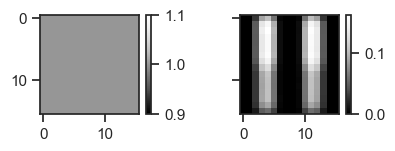

In [8]:
log_scale = tonp(tr.model.layer.get_dec_log_sigma().squeeze())
var_learned = (np.exp(log_scale) ** 2).reshape(16, 16)

var_data = tonp(tr.dl_vld.dataset.tensors[0].var(dim=0).squeeze())

fig, axes =  create_figure(1, 2, (4, 1.4), sharex='all', sharey='all')
im = axes[0].imshow(var_learned, cmap='Greys_r')
plt.colorbar(im, ax=axes[0])
im = axes[1].imshow(var_data, cmap='Greys_r')
plt.colorbar(im, ax=axes[1])

plt.show()

In [9]:
# cm = ''
# tr.train(fit_name=f"{cm}_{tr.cfg.name()}")

tr.train()

epoch # 1000, avg loss: -451.908: 100%|███| 1000/1000 [3:17:31<00:00, 11.85s/it]


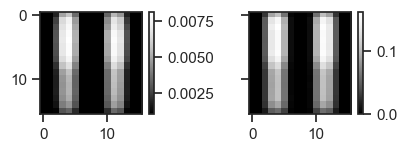

In [10]:
log_scale = tonp(tr.model.layer.get_dec_log_sigma().squeeze())
var_learned = (np.exp(log_scale) ** 2).reshape(16, 16)

var_data = tonp(tr.dl_vld.dataset.tensors[0].var(dim=0).squeeze())

fig, axes =  create_figure(1, 2, (4, 1.4), sharex='all', sharey='all')
im = axes[0].imshow(var_learned, cmap='Greys_r')
plt.colorbar(im, ax=axes[0])
im = axes[1].imshow(var_data, cmap='Greys_r')
plt.colorbar(im, ax=axes[1])

plt.show()

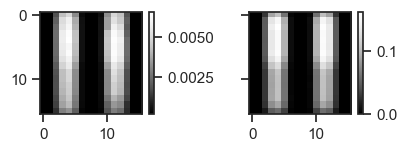

In [10]:
### Was: dec_clamp = 4.6

In [11]:
tuple(llr.exp() for llr in tr.model.layer.log_lr)

(tensor([0.0554], device='cuda:0', grad_fn=<ExpBackward0>),)

In [12]:
print(tr.model.layer.n_exp)

tensor([174, 222, 258, 281, 293, 300, 305, 308, 311, 312, 315, 317, 317, 320,
        320, 322, 323, 324, 324, 325, 326, 326, 326, 327, 328, 330, 330, 330,
        330, 332, 332, 333], device='cuda:0', dtype=torch.int32)

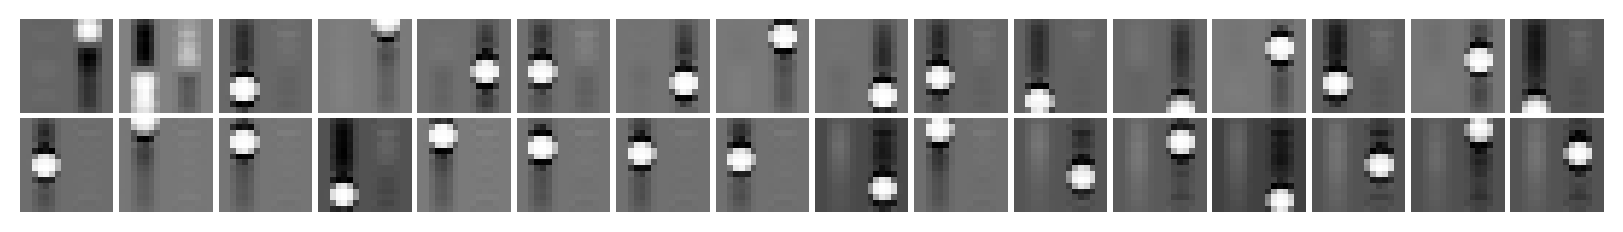

In [13]:
u0 = tonp(tr.model.layer.u_init[0].squeeze())
tr.model.show(order=np.argsort(u0), nrows=2);

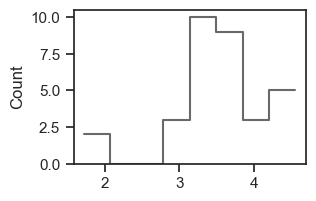

In [14]:
histplot(u0, color='dimgrey')
plt.show()

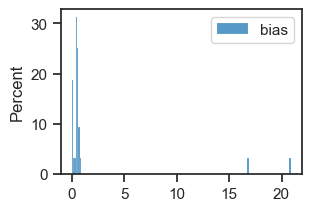

In [15]:
fig, ax = create_figure()

sns.histplot(tonp(tr.model.layer.log_bias.squeeze().exp()), label='bias', stat='percent',  ax=ax)
ax.legend()
plt.show()

100%|███████████████████████████████████| 2/2 [00:03<00:00,  1.80s/it]


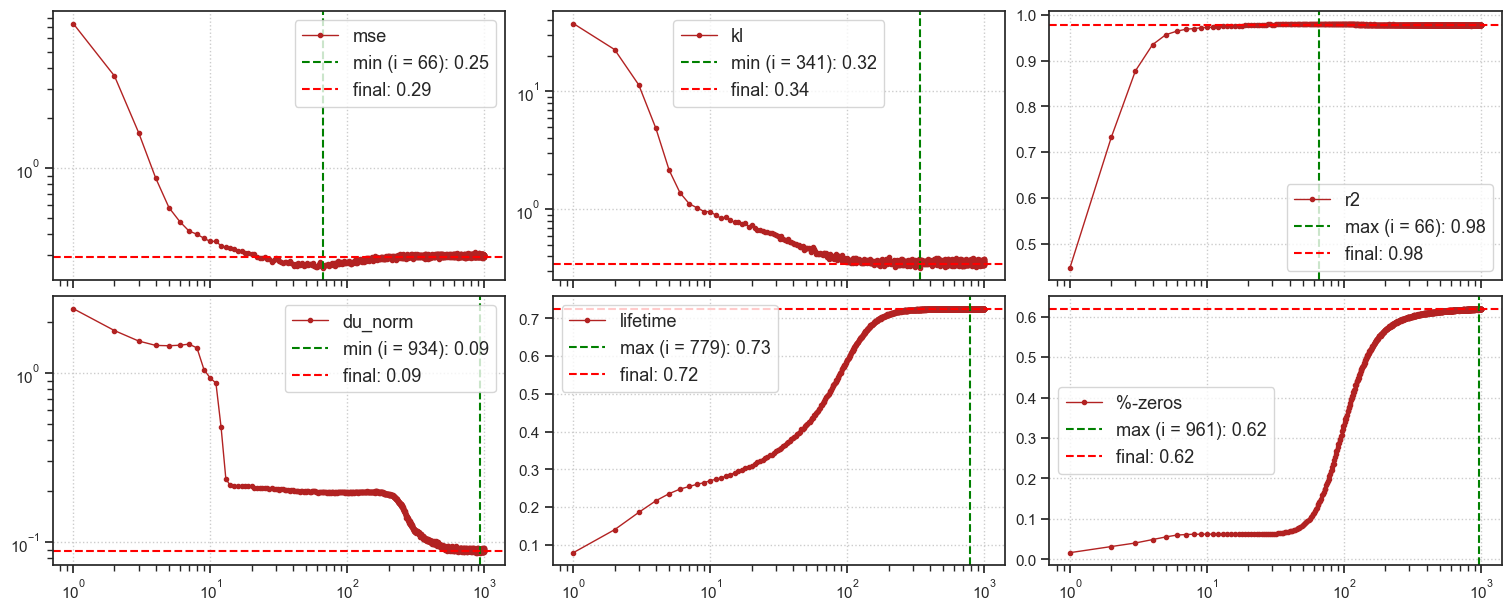

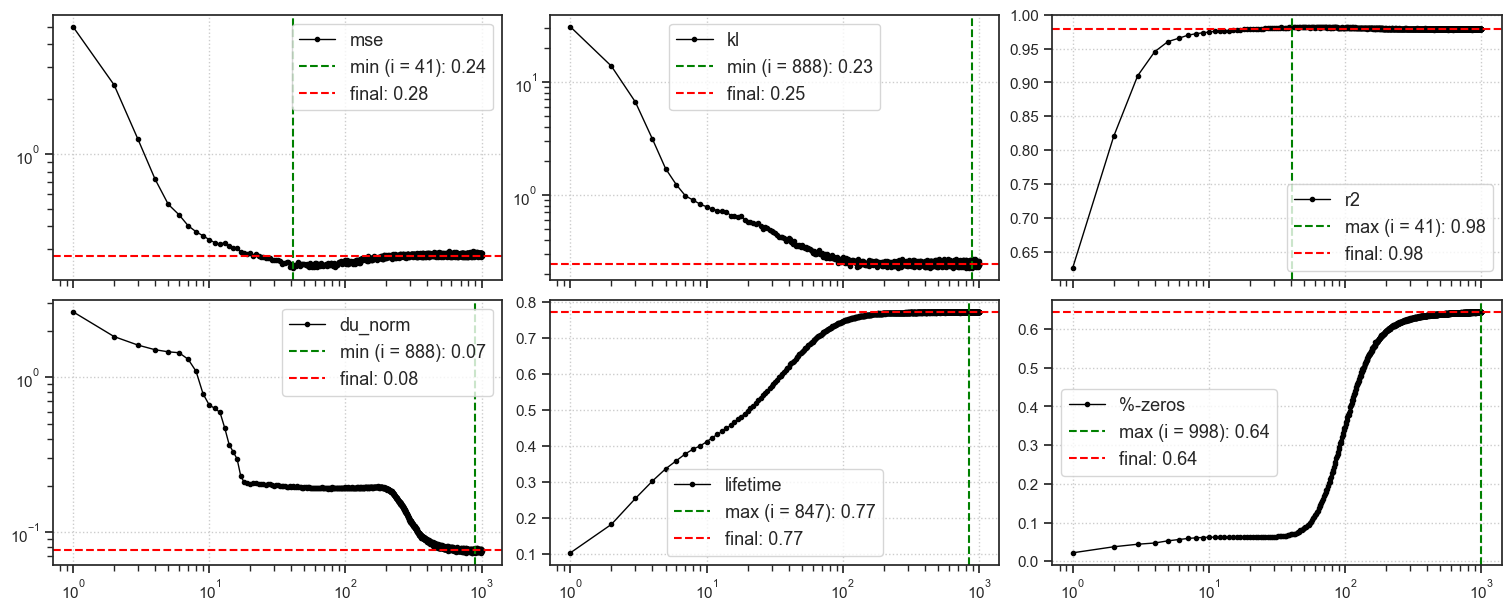

CPU times: user 9.94 s, sys: 31.8 ms, total: 9.97 s
Wall time: 9.96 s


In [16]:
%%time

kws = dict(
    seq_total=1000,
    seq_batch_sz=1000,
    n_data_batches=2,
)
results = {
    k: tr.analysis(k, **kws)
    for k in ['vld', 'tst']
}
_ = plot_convergence(results['tst'], color='firebrick')
_ = plot_convergence(results['vld'], color='k')

## r2 score

In [17]:
from base.helper import find_weight_concentrations
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import r2_score

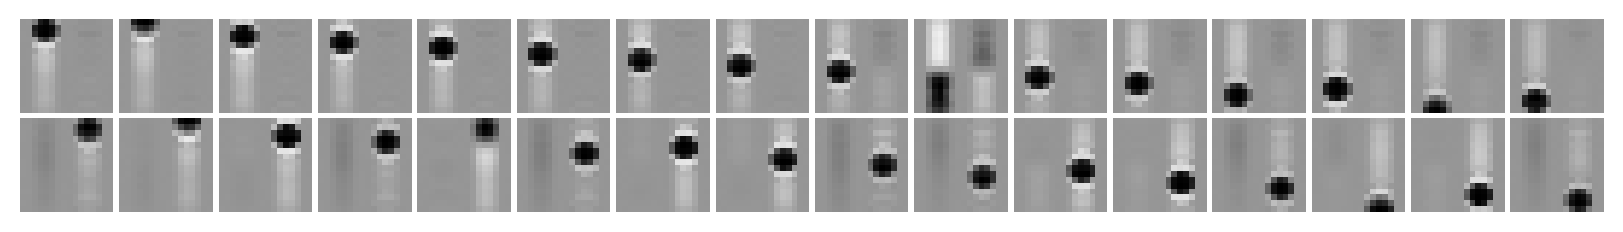

In [18]:
w = tr.model.layer.get_weight()
w = tonp(w.T).reshape(32, 16, 16)
ordered_indices, centers = find_weight_concentrations(
    w, lambda p: p[0] + (p[1] > 6).astype(float) * 50)

tr.model.show(order=ordered_indices, nrows=2, method='abs-max');

In [19]:
%%time


seq_total = 1000
selection = ['u', 'samples', 'r2']

kws_dl = dict(
    batch_size=1000,
    drop_last=False,
    shuffle=False,
)

results = {}
for item in ['trn', 'vld', 'tst']:
    # create data loader without shuffle
    ds = getattr(tr, f"dl_{item}").dataset
    dl = torch.utils.data.DataLoader(ds, **kws_dl)
    data = collections.defaultdict(list)
    for x, g in tqdm(iter(dl)):
        output = tr.model.xtract_ftr(
            feeder=tr.get_feeder(x),
            seq=range(seq_total),
            return_extras=True,
        ).stack()
        data['g'].append(g)
        for key in selection:
            data[key].append(output[key][:, -1])
        data['lamb'].append(output['u'][:, -1].exp())
    data = {
        k: tonp(torch.cat(v)) for
        k, v in data.items()
    }
    results[item] = data

100%|███████████████████████████████████████████| 50/50 [01:30<00:00,  1.81s/it]

CPU times: user 3min 55s, sys: 135 ms, total: 3min 55s
Wall time: 3min 55s


In [20]:
var = 'lamb'

lr = LinearRegression().fit(
    X=results['trn'][var],
    y=results['trn']['g'][:, [1, 3]],
)
r2 = {
    name: r2_score(
        y_true=d['g'][:, [1, 3]],
        y_pred=lr.predict(d[var]),
        multioutput='raw_values')
    for name, d in results.items()
}
corr = {
    name: 1 - np.diag(sp_dist.cdist(
        XA=d['g'][:, [1, 3]].T,
        XB=lr.predict(d[var]).T,
        metric='correlation',
    )) for name, d in results.items()
}

In [21]:
print(f"r2:", r2, '\nCorr:', corr)

r2:
{
    'trn': array([0.997492  , 0.99721324], dtype=float32),
    'vld': array([0.9974349 , 0.99713254], dtype=float32),
    'tst': array([0.9838858, 0.983834 ], dtype=float32)
}

Corr:
{
    'trn': array([0.99874522, 0.99860563]),
    'vld': array([0.99871687, 0.99856538]),
    'tst': array([0.99238757, 0.99193992])
}